In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import pickle
import networkx as nx

In [17]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.tsa.api import VAR
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACIÓN
# =====================================================

N_BOOTSTRAP = 300
MIN_PRESENCIA = 2
ALPHA = 0.05
MIN_VAR = 1e-10
ABUNDANCIA_MINIMA = 0.5

WINDOWS = {
    "9798_6253": (9798, 6253)
    #"6182_3842": (6182, 3842)
    #"3771_-57": (3771, -57)
}

# =====================================================
# FUNCIONES
# =====================================================

def es_serie_valida(serie):
    return (serie > 0).sum() >= MIN_PRESENCIA 

def bootstrap_univariante_exp_paper(serie):
    """
    Implementa el stationary bootstrap exactamente como en el paper:
    - Usa serie duplicada para permitir bloques que crucen el final
    - Los bloques son siempre contiguos en el tiempo
    """
    n = len(serie)
    # Duplicar la serie para permitir cruce del final sin usar módulo
    serie_period = np.concatenate((serie, serie))
    
    resultado = np.array([])
    
    while len(resultado) < n:
        # Generar longitud de bloque (exponencial con media = n)
        L = int(np.random.exponential(scale=n))
        while L > n:  # Asegurar que L no exceda n
            L = int(np.random.exponential(scale=n))
        
        # Punto de inicio aleatorio (0 a n-1)
        inicio = np.random.randint(0, n)
        
        # Calcular cuántos puntos necesitamos aún
        restantes = n - len(resultado)
        L_actual = min(L, restantes)
        
        # Extraer bloque contiguo de serie_period
        bloque = serie_period[inicio:inicio + L_actual]
        resultado = np.concatenate((resultado, bloque))
    
    return resultado

def generar_bootstrap_df(df, columnas):
    """
    Genera un dataframe bootstrap usando stationary bootstrap
    """
    df_boot = pd.DataFrame()
    df_boot["cal BP"] = df["cal BP"].values
    df_boot["Temperatura"] = df["Temperatura"].values
    df_boot["Multiplier"] = df["Multiplier"].values

    for col in columnas:
        df_boot[col] = bootstrap_univariante_exp_paper(df[col].values)

    return df_boot

def extraer_ventana(df, cal_min, cal_max):
    mask = (df["cal BP"] >= min(cal_min, cal_max)) & \
           (df["cal BP"] <= max(cal_min, cal_max))
    return df[mask].copy().reset_index(drop=True)

def coef_sp1_a_sp2_condicional(df, sp1, sp2, return_zero_on_fail=True):
    """
    Calcula el coeficiente de Granger sp1 -> sp2
    Si falla, retorna 0 (como en el paper)
    """
    # añadir condicionales (temperatura y multipliers)
    try:
        x = df[sp1].values
        y = df[sp2].values
        temp = df["Temperatura"].values
        mult = df["Multiplier"].values

        if (np.std(x) < MIN_VAR or
            np.std(y) < MIN_VAR or
            np.std(temp) < MIN_VAR or
            np.std(mult) < MIN_VAR):
            return 0

        data = pd.DataFrame({
            sp1: x,
            sp2: y,
            "Temp": temp,
            "Mult": mult
        })

        model = VAR(data)
        results = model.fit(maxlags=1)
        
        coef = results.coefs[0][1][0]  # sp1 -> sp2
        
        return float(coef)

    except Exception as e:
        return 0.0  # Como en el paper, retornar 0 si falla

# =====================================================
# CARGAR DATOS
# =====================================================

with open("series_equidistantes_gam_delta_mult.pkl", "rb") as f:
    df_original = pickle.load(f)

# Invertir orden temporal (cal BP va de mayor a menor = más antiguo a más reciente)
df_original = df_original.sort_values("cal BP", ascending=False).reset_index(drop=True)

especies_cols = [c for c in df_original.columns if c != "cal BP" and c != "Temperatura" and c != "Multiplier"]

df_original[especies_cols] = df_original[especies_cols].where(
    df_original[especies_cols] >= ABUNDANCIA_MINIMA, 0
)

# Identificar especies válidas en toda la serie
especies_globales = [
    sp for sp in especies_cols
    if es_serie_valida(df_original[sp])
]

print(f"Especies válidas en serie completa: {len(especies_globales)}")

np.random.seed(42)

# =====================================================
# GENERAR BOOTSTRAPS
# =====================================================

print("\nGenerando bootstrap...")

boot_dfs = [
    generar_bootstrap_df(df_original, especies_globales)
    for _ in range(N_BOOTSTRAP)
]

print(f"{N_BOOTSTRAP} bootstraps generados.")

# =====================================================
# ANÁLISIS POR VENTANAS
# =====================================================

for window_name, (cmin, cmax) in WINDOWS.items():

    print("\n" + "="*60)
    print("VENTANA:", window_name)
    print("="*60)

    df_w = extraer_ventana(df_original, cmin, cmax)
    print(f"Tamaño ventana: {len(df_w)} observaciones")

    # Especies válidas dentro de ventana
    especies_ventana = [
        sp for sp in especies_globales
        if es_serie_valida(df_w[sp])
    ]

    n_w = len(especies_ventana)
    print(f"Especies válidas en ventana: {n_w}")

    if n_w < 2:
        print("Muy pocas especies, se omite ventana")
        continue

    # Extraer ventanas de los bootstraps
    boot_windows = [
        extraer_ventana(df_b, cmin, cmax)
        for df_b in boot_dfs
    ]

    matriz_coef = np.full((n_w, n_w), np.nan)
    matriz_sig = np.zeros((n_w, n_w))
    matriz_pvalor = np.full((n_w, n_w), np.nan)

    total_pairs = 0
    valid_original = 0
    bootstrap_fail = 0
    n_sig = 0
    n_low = 0
    n_high = 0

    # =====================================================
    # LOOP SOBRE PARES DE ESPECIES
    # =====================================================

    for i, sp1 in enumerate(especies_ventana):
        for j, sp2 in enumerate(especies_ventana):
            if i == j:
                continue

            total_pairs += 1

            # Coeficiente original
            coef_original = coef_sp1_a_sp2_condicional(df_w, sp1, sp2)
            matriz_coef[i, j] = coef_original

            # Coeficientes bootstrap
            coefs_boot = []
            for df_b_w in boot_windows:
                coef_boot = coef_sp1_a_sp2_condicional(df_b_w, sp1, sp2)
                coefs_boot.append(coef_boot)  # Siempre añadimos (retorna 0 si falla)

            coefs_boot = np.array(coefs_boot)
            valid_original += 1

            # Verificar si hay suficientes boots NO CERO para tener varianza
            if np.std(coefs_boot) < MIN_VAR:
                bootstrap_fail += 1
                # Si todos los boots son iguales (ej. todos 0), no podemos calcular p-valor
                matriz_pvalor[i, j] = 1.0
                continue

            # =====================================================
            # CÁLCULO DEL P-VALOR BOOTSTRAP (MÉTODO DEL PAPER)
            # =====================================================
            # p-valor = (número de boots con |coef| >= |coef_original| + 1) / (nboots + 1)
            
            n_extremos = np.sum(np.abs(coefs_boot) >= np.abs(coef_original))
            p_valor = (n_extremos + 1) / (len(coefs_boot) + 1)
            matriz_pvalor[i, j] = p_valor

            # Decisión de significancia
            if p_valor < ALPHA:
                n_sig += 1
                if coef_original > 0:
                    matriz_sig[i, j] = 1
                    n_high += 1
                else:
                    matriz_sig[i, j] = -1
                    n_low += 1

    # =====================================================
    # DIAGNÓSTICO
    # =====================================================

    print("\n--- DIAGNÓSTICO ---")
    print(f"Pares totales evaluados: {total_pairs}")
    print(f"Pares con coeficiente válido: {valid_original} ({valid_original/total_pairs*100:.2f}%)")

    if valid_original > 0:
        print(f"Pares sin varianza en bootstrap: {bootstrap_fail} ({bootstrap_fail/valid_original*100:.2f}% de válidos)")
        print(f"\nSignificativos (p < {ALPHA}): {n_sig} ({n_sig/valid_original*100:.2f}% de válidos)")
        print(f"  Negativos (cola baja): {n_low} ({n_low/n_sig*100:.1f}% de significativos)")
        print(f"  Positivos (cola alta): {n_high} ({n_high/n_sig*100:.1f}% de significativos)")

    # =====================================================
    # GUARDAR RESULTADOS
    # =====================================================

    resultado = {
        "especies": especies_ventana,
        "matriz_coeficientes": matriz_coef,
        "matriz_significancia": matriz_sig,
        "matriz_pvalores": matriz_pvalor,
        "n_bootstrap": N_BOOTSTRAP,
        "alpha": ALPHA
    }

    nombre_archivo = f"red_granger_{window_name}_def.pkl"
    with open(nombre_archivo, "wb") as f:
        pickle.dump(resultado, f)

    print(f"\nGuardado: {nombre_archivo}")

print("\nProceso terminado correctamente.")

Especies válidas en serie completa: 74

Generando bootstrap...
300 bootstraps generados.

VENTANA: 9798_6253
Tamaño ventana: 51 observaciones
Especies válidas en ventana: 65

--- DIAGNÓSTICO ---
Pares totales evaluados: 4160
Pares con coeficiente válido: 4160 (100.00%)
Pares sin varianza en bootstrap: 0 (0.00% de válidos)

Significativos (p < 0.05): 372 (8.94% de válidos)
  Negativos (cola baja): 117 (31.5% de significativos)
  Positivos (cola alta): 255 (68.5% de significativos)

Guardado: red_granger_9798_6253_def.pkl

Proceso terminado correctamente.



Coeficientes extremos encontrados:
Juglans → Papaver 1387.0195684044097
Centaurea → Valerianaceae 18556.801208226632
Papaver → Juglans -1385.4290126967562
Valerianaceae → Centaurea -18556.444732883596

Analizando par:
Juglans → Papaver


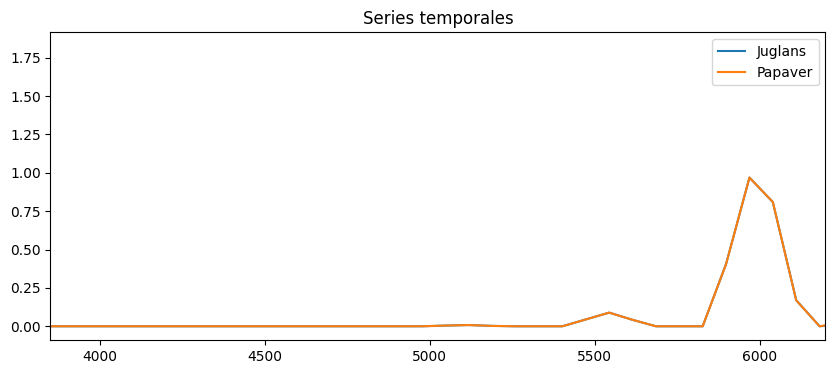

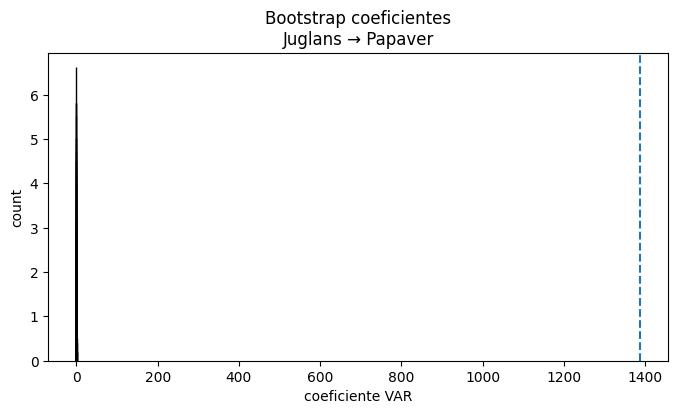


Estadísticos bootstrap:
media: -0.0016210494668027777
std: 0.07758658098399955
p2.5: -0.12918368110525172
p97.5: 0.16438110014583907


In [7]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# ================================
# CONFIG
# ================================

ARCHIVO_RED = "results_w2_0.1.pkl"   # segunda ventana
ARCHIVO_SERIES = "series_equidistantes_gam.pkl"

N_BOOTSTRAP = 1000
THRESHOLD = 1000   # para detectar coeficientes absurdos


# ================================
# FUNCIONES
# ================================

def bootstrap_univariante_exp(serie):

    n = len(serie)
    resultado = []

    while len(resultado) < n:

        inicio = np.random.randint(0, n)

        longitud = int(np.random.exponential(scale=n))
        longitud = max(1, min(longitud, n))

        indices = (inicio + np.arange(longitud)) % n
        resultado.extend(serie[indices])

    return np.array(resultado[:n])


def coef_sp1_a_sp2(df, sp1, sp2):

    x = df[sp1].values
    y = df[sp2].values

    data = pd.DataFrame({sp1: x, sp2: y})

    model = VAR(data)
    results = model.fit(maxlags=1)

    A = results.coefs[0]

    return A[1][0]


# ================================
# CARGAR RESULTADOS
# ================================

with open(ARCHIVO_RED, "rb") as f:
    red = pickle.load(f)

matriz = red["matriz_coeficientes"]
especies = red["especies"]

# ================================
# BUSCAR COEFICIENTES EXTREMOS
# ================================

mask = np.abs(matriz) > THRESHOLD

indices = np.argwhere(mask)

if len(indices) == 0:
    print("No se encontraron coeficientes > threshold")
    exit()

print("\nCoeficientes extremos encontrados:")

for i, j in indices:

    print(especies[i], "→", especies[j], matriz[i, j])

# tomamos el primero
i, j = indices[0]

sp1 = especies[i]
sp2 = especies[j]

print("\nAnalizando par:")
print(sp1, "→", sp2)

coef_original = matriz[i, j]

# ================================
# CARGAR SERIES
# ================================

with open(ARCHIVO_SERIES, "rb") as f:
    df = pickle.load(f)

serie1 = df[sp1]
serie2 = df[sp2]
t = df["cal BP"]

# ================================
# PLOT SERIES TEMPORALES
# ================================

plt.figure(figsize=(10,4))

plt.plot(t, serie1, label=sp1)
plt.plot(t, serie2, label=sp2)
plt.xlim(6200, 3850)
plt.gca().invert_xaxis()

plt.title("Series temporales")
plt.legend()

plt.show()

# ================================
# BOOTSTRAP
# ================================

coefs_boot = []

df_pair = pd.DataFrame({
    sp1: serie1.values,
    sp2: serie2.values
})

for _ in range(N_BOOTSTRAP):

    s1 = bootstrap_univariante_exp(serie1.values)
    s2 = bootstrap_univariante_exp(serie2.values)

    df_b = pd.DataFrame({
        sp1: s1,
        sp2: s2
    })

    try:

        coef = coef_sp1_a_sp2(df_b, sp1, sp2)
        coefs_boot.append(coef)

    except:
        continue


coefs_boot = np.array(coefs_boot)

# ================================
# PLOT DISTRIBUCIÓN BOOTSTRAP
# ================================

plt.figure(figsize=(8,4))

plt.hist(coefs_boot, bins=50, color="skyblue", edgecolor="black", density=True)

plt.axvline(coef_original, linestyle="--")

plt.title(f"Bootstrap coeficientes\n{sp1} → {sp2}")

plt.xlabel("coeficiente VAR")
plt.ylabel("count")

plt.show()

print("\nEstadísticos bootstrap:")

print("media:", np.mean(coefs_boot))
print("std:", np.std(coefs_boot))
print("p2.5:", np.percentile(coefs_boot, 2.5))
print("p97.5:", np.percentile(coefs_boot, 97.5))


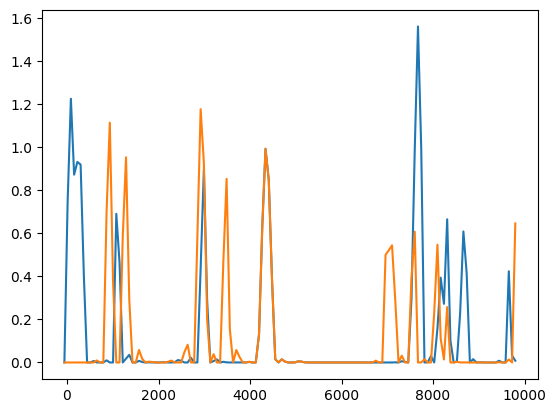

In [14]:
#plotear series de Centaurea y Valerianaceae
sp1="Centaurea"
sp2="Valerianaceae"
plt.plot(df["cal BP"], df[sp1], label=sp1)
plt.plot(df["cal BP"], df[sp2], label=sp2)

(-1.0, 1.0)

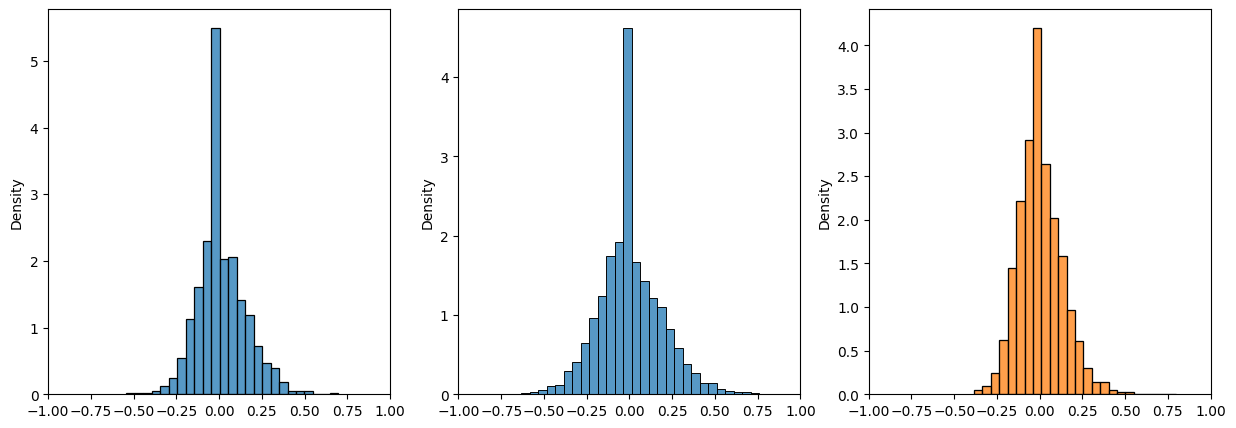

In [8]:
#histograma de los coeficientes por ventana, 3 figuras en una imagen

import seaborn as sns
import matplotlib.pyplot as plt
with open("results_w1_delta.pkl", "rb") as f:
    data_1 = pickle.load(f)

coef_1 = data_1["matriz_coeficientes"]

with open("results_w2_delta.pkl", "rb") as f:
    data_2 = pickle.load(f)

coef_2 = data_2["matriz_coeficientes"]
coef_2_buenos=coef_2[(coef_2>-1) & (coef_2<1)]

with open("results_w3_delta.pkl", "rb") as f:
    data_3 = pickle.load(f)

coef_3 = data_3["matriz_coeficientes"]

plt.subplots(1, 3, figsize=(15, 5))
# histogramas normalizados con seaborn, con un ancho de barra de 0.05, 
sns.histplot()

sns.histplot(coef_1.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 1), stat="density")
sns.histplot(coef_2_buenos.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 2), stat="density")
sns.histplot(coef_3.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 3), stat="density")

#xlims
plt.subplot(1, 3, 1).set_xlim(-1, 1)
plt.subplot(1, 3, 2).set_xlim(-1, 1)
plt.subplot(1, 3, 3).set_xlim(-1, 1)



(0.0, 500.0)

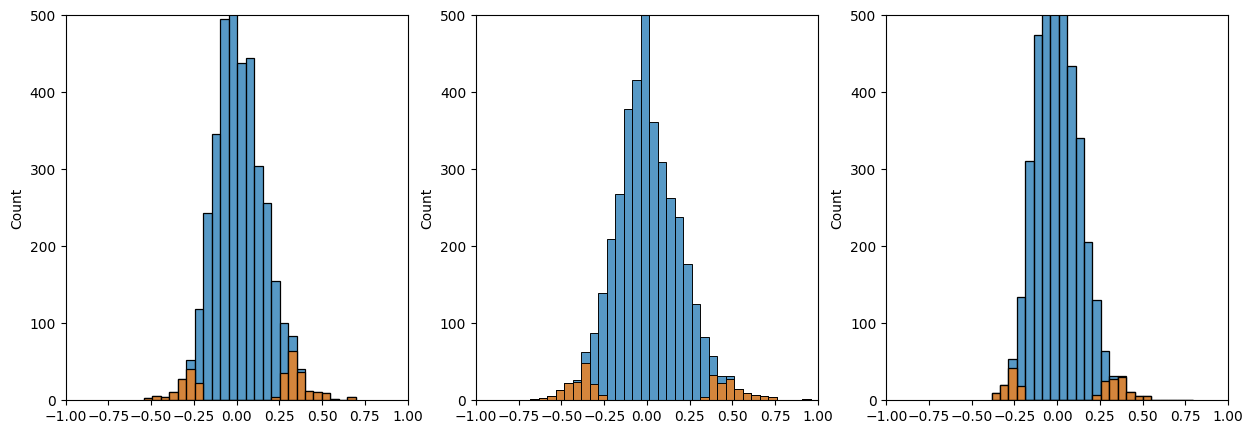

In [9]:
#sabiendo que matriz_sig tiene el mismo formato que matriz_coeficientes, hacer un histograma de los coeficientes significativos, es decir, aquellos para los que matriz_sig es distinto de cero, para cada ventana. Hacerlo en la misma figura, con tres subplots, uno para cada ventana.
#en matriz sig hay un 1 o -1 para coeficientes significativos y un 0 para los no significativos, 
# hay que coger los coeficientes correspondientes a los 1 y -1 de matriz_sig, y hacer un histograma de esos coeficientes, 

matriz_sig_1 = data_1["matriz_significancia"]
coefs_1_significativos = []
for i in range(len(matriz_sig_1)):
    for j in range(len(matriz_sig_1[i])):
        if matriz_sig_1[i][j] != 0:
            coefs_1_significativos.append(coef_1[i][j])

matriz_sig_2 = data_2["matriz_significancia"]
coefs_2_significativos = []
for i in range(len(matriz_sig_2)):
    for j in range(len(matriz_sig_2[i])):
        if matriz_sig_2[i][j] != 0:
            if coef_2[i][j]>-1 and coef_2[i][j]<1:
                coefs_2_significativos.append(coef_2[i][j])

matriz_sig_3 = data_3["matriz_significancia"]
coefs_3_significativos = []
for i in range(len(matriz_sig_3)):
    for j in range(len(matriz_sig_3[i])):
        if matriz_sig_3[i][j] != 0:
            coefs_3_significativos.append(coef_3[i][j])

plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(coef_1.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 1), )
sns.histplot(coef_2_buenos.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 2), )
sns.histplot(coef_3.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 3),)
sns.histplot(coefs_1_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 1), )
sns.histplot(coefs_2_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 2), )
sns.histplot(coefs_3_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 3), )


#xlims
plt.subplot(1, 3, 1).set_xlim(-1, 1)
plt.subplot(1, 3, 2).set_xlim(-1, 1)
plt.subplot(1, 3, 3).set_xlim(-1, 1)
plt.subplot(1, 3, 1).set_ylim(0, 500)
plt.subplot(1, 3, 2).set_ylim(0, 500)
plt.subplot(1, 3, 3).set_ylim(0, 500)

(0.0, 500.0)

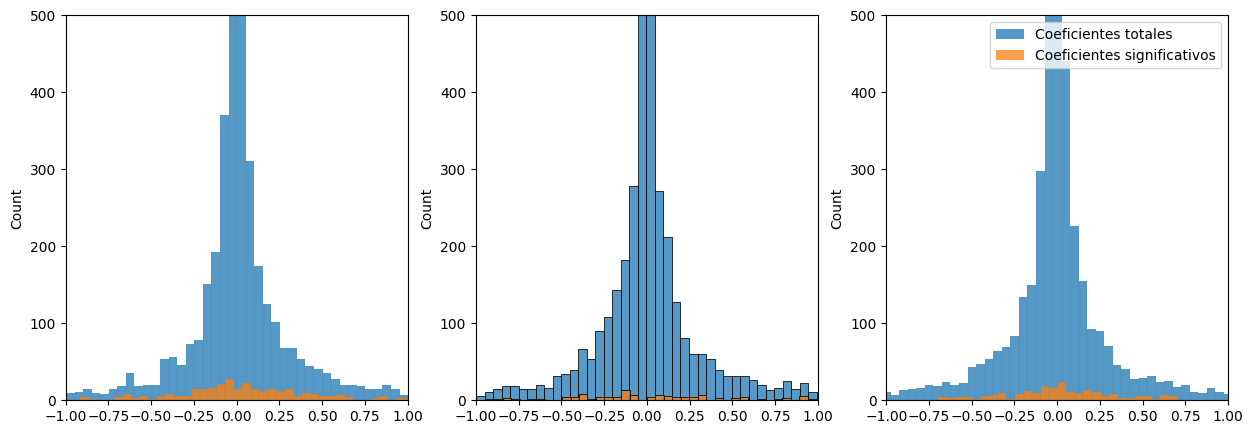

In [11]:
with open("results_w1_0.1.pkl", "rb") as f:
    data_1 = pickle.load(f)

with open("results_w2_0.1.pkl", "rb") as f:
    data_2 = pickle.load(f)

with open("results_w3_0.1.pkl", "rb") as f:
    data_3 = pickle.load(f)


matriz_sig_1 = data_1["matriz_significancia"]
coef_1 = data_1["matriz_coeficientes"]
coefs_1_significativos = []
for i in range(len(matriz_sig_1)):
    for j in range(len(matriz_sig_1[i])):
        if matriz_sig_1[i][j] != 0:
            coefs_1_significativos.append(coef_1[i][j])

matriz_sig_2 = data_2["matriz_significancia"]
coef_2 = data_2["matriz_coeficientes"]
coefs_2_significativos = []
for i in range(len(matriz_sig_2)):
    for j in range(len(matriz_sig_2[i])):
        if coef_2[i][j]<-1 or coef_2[i][j]>1:
            coef_2[i][j]=np.nan
        if matriz_sig_2[i][j] != 0:
            if coef_2[i][j]>-1 and coef_2[i][j]<1:
                coefs_2_significativos.append(coef_2[i][j])

matriz_sig_3 = data_3["matriz_significancia"]
coef_3 = data_3["matriz_coeficientes"]
coefs_3_significativos = []
for i in range(len(matriz_sig_3)):
    for j in range(len(matriz_sig_3[i])):
        if matriz_sig_3[i][j] != 0:
            coefs_3_significativos.append(coef_3[i][j])

plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(coef_1.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 1), )
sns.histplot(coef_2.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 2), )
sns.histplot(coef_3.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 3),)
sns.histplot(coefs_1_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 1), )
sns.histplot(coefs_2_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 2), )
sns.histplot(coefs_3_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 3), )

plt.legend(["Coeficientes totales", "Coeficientes significativos"], loc="upper right")
#xlims
plt.subplot(1, 3, 1).set_xlim(-1, 1)
plt.subplot(1, 3, 2).set_xlim(-1, 1)
plt.subplot(1, 3, 3).set_xlim(-1, 1)
plt.subplot(1, 3, 1).set_ylim(0, 500)
plt.subplot(1, 3, 2).set_ylim(0, 500)
plt.subplot(1, 3, 3).set_ylim(0, 500)

(-1.0, 1.0)

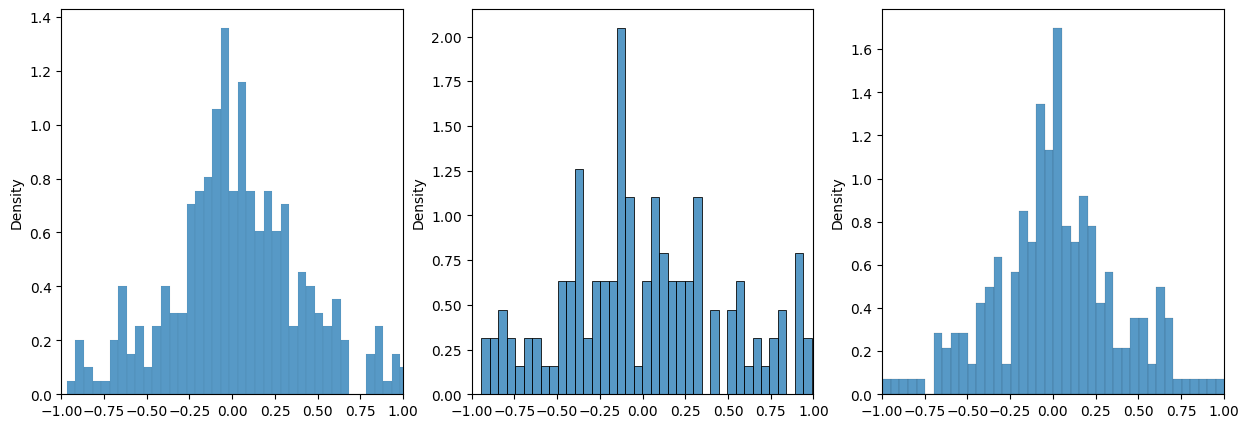

In [12]:

plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(coefs_1_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 1), stat="density") 
sns.histplot(coefs_2_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 2), stat="density") 
sns.histplot(coefs_3_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 3), stat="density") 

plt.subplot(1, 3, 1).set_xlim(-1, 1)
plt.subplot(1, 3, 2).set_xlim(-1, 1)
plt.subplot(1, 3, 3).set_xlim(-1, 1)

In [ ]:
with open("results_w1_0.1.pkl", "rb") as f:
    data_1 = pickle.load(f)

with open("results_w2_0.1.pkl", "rb") as f:
    data_2 = pickle.load(f)

with open("results_w3_0.1.pkl", "rb") as f:
    data_3 = pickle.load(f)

matriz_sig_1 = data_1["matriz_significancia"]
coef_1 = data_1["matriz_coeficientes"]
coefs_1_significativos = []
for i in range(len(matriz_sig_1)):
    for j in range(len(matriz_sig_1[i])):
        if matriz_sig_1[i][j] != 0:
            coefs_1_significativos.append(coef_1[i][j])

matriz_sig_2 = data_2["matriz_significancia"]
coef_2 = data_2["matriz_coeficientes"]
coefs_2_significativos = []
for i in range(len(matriz_sig_2)):
    for j in range(len(matriz_sig_2[i])):
        if matriz_sig_2[i][j] != 0:
            coefs_2_significativos.append(coef_2[i][j])

matriz_sig_3 = data_3["matriz_significancia"]
coef_3 = data_3["matriz_coeficientes"]
coefs_3_significativos = []
for i in range(len(matriz_sig_3)):
    for j in range(len(matriz_sig_3[i])):
        if matriz_sig_3[i][j] != 0:
            coefs_3_significativos.append(coef_3[i][j])


print(max(coefs_1_significativos), max(coefs_2_significativos), max(coefs_3_significativos))
print(min(coefs_1_significativos), min(coefs_2_significativos), min(coefs_3_significativos))

Número coefs sig. positivos 207
Número coefs sig. negativos 190
Número coefs sig. totales 397
Porcentaje negativos 0.47858942065491183
Número coefs sig. positivos 110
Número coefs sig. negativos 121
Número coefs sig. totales 231
Porcentaje negativos 0.5238095238095238
Número coefs sig. positivos 153
Número coefs sig. negativos 129
Número coefs sig. totales 282
Porcentaje negativos 0.4574468085106383


(0.0, 500.0)

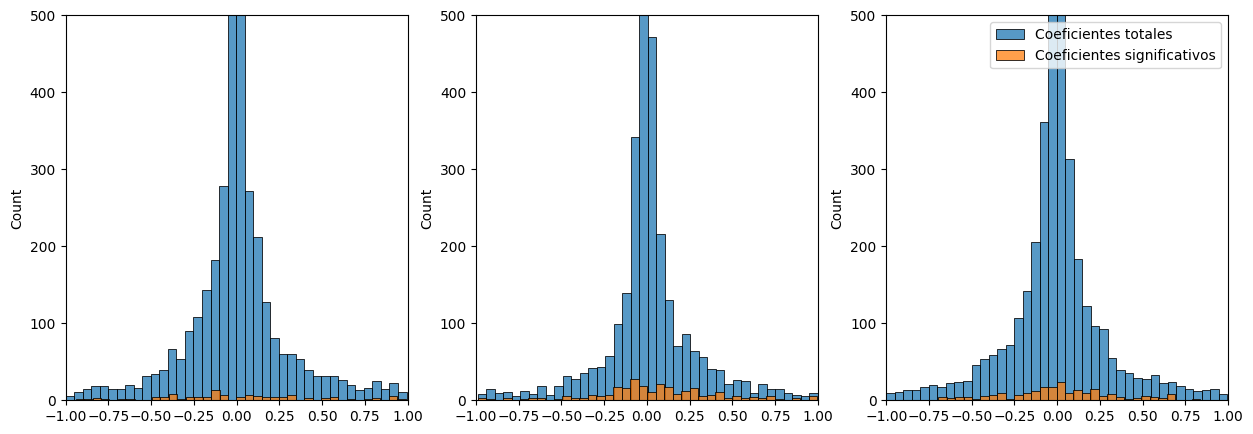

In [13]:
with open("results_w2_0.1.pkl", "rb") as f:
    data_1 = pickle.load(f)

with open("red_granger_9798_6253.pkl", "rb") as f:
    data_2 = pickle.load(f)

with open("results_w3_0.1.pkl", "rb") as f:
    data_3 = pickle.load(f)


matriz_sig_1 = data_1["matriz_significancia"]
coef_1 = data_1["matriz_coeficientes"]
coefs_1_significativos = []
for i in range(len(matriz_sig_1)):
    for j in range(len(matriz_sig_1[i])):
        if coef_1[i][j]<-1 or coef_1[i][j]>1:
            coef_1[i][j]=np.nan
        if matriz_sig_1[i][j] != 0:
            if coef_1[i][j]>-1 and coef_1[i][j]<1:
                coefs_1_significativos.append(coef_1[i][j])

matriz_sig_2 = data_2["matriz_significancia"]
coef_2 = data_2["matriz_coeficientes"]
coefs_2_significativos = []
for i in range(len(matriz_sig_2)):
    for j in range(len(matriz_sig_2[i])):
        if coef_2[i][j]<-1 or coef_2[i][j]>1:
            coef_2[i][j]=np.nan
        if matriz_sig_2[i][j] != 0:
            if coef_2[i][j]>-1 and coef_2[i][j]<1:
                coefs_2_significativos.append(coef_2[i][j])

matriz_sig_3 = data_3["matriz_significancia"]
coef_3 = data_3["matriz_coeficientes"]
coefs_3_significativos = []
for i in range(len(matriz_sig_3)):
    for j in range(len(matriz_sig_3[i])):
        if coef_3[i][j]<-1 or coef_3[i][j]>1:
            coef_3[i][j]=np.nan
        if matriz_sig_3[i][j] != 0:
            if coef_3[i][j]>-1 and coef_3[i][j]<1:
                coefs_3_significativos.append(coef_3[i][j])

plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(coef_1.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 1), )
sns.histplot(coef_2.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 2), )
sns.histplot(coef_3.flatten(), binwidth=0.05, ax=plt.subplot(1, 3, 3),)
sns.histplot(coefs_1_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 1), )
sns.histplot(coefs_2_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 2), )
sns.histplot(coefs_3_significativos, binwidth=0.05, ax=plt.subplot(1, 3, 3), )

plt.legend(["Coeficientes totales", "Coeficientes significativos"], loc="upper right")
#xlims
plt.subplot(1, 3, 1).set_xlim(-1, 1)
plt.subplot(1, 3, 2).set_xlim(-1, 1)
plt.subplot(1, 3, 3).set_xlim(-1, 1)
plt.subplot(1, 3, 1).set_ylim(0, 500)
plt.subplot(1, 3, 2).set_ylim(0, 500)
plt.subplot(1, 3, 3).set_ylim(0, 500)

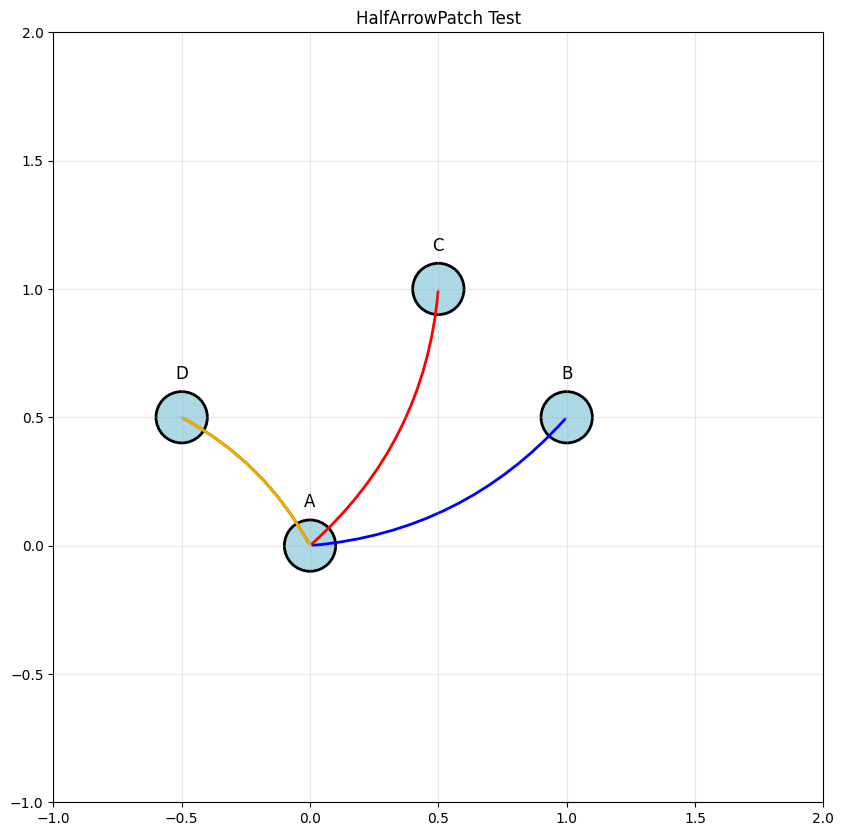

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *

class HalfArrowPatch(FancyArrowPatch):
    """
    A custom arrow patch that draws arrows with half arrowheads.
    Useful for drawing multiple parallel edges between nodes.
    """
    
    def __init__(self, posA, posB, marker='-|>', width=1, height=1, 
                 color='black', linewidth=1, curvature=0.3, 
                 arrow_linewidth=2, **kwargs):
        """
        Initialize a HalfArrowPatch.
        
        Parameters:
        -----------
        posA, posB : tuples
            Starting and ending positions (x, y)
        marker : str
            Arrow style ('-|>' for right half, '|\\' for left half, etc.)
        width, height : float
            Width and height of the arrowhead
        color : str or tuple
            Arrow color
        linewidth : float
            Width of the arrow shaft
        curvature : float
            Curvature of the arrow (0 = straight, >0 = curved)
        arrow_linewidth : float
            Width of the arrowhead lines
        **kwargs : additional arguments for FancyArrowPatch
        """
        # Store parameters
        self.marker = marker
        self.arrow_width = width
        self.arrow_height = height
        self.arrow_linewidth = arrow_linewidth
        self.curvature = curvature
        
        # Initialize the parent class
        super().__init__(posA, posB, 
                        connectionstyle=f"arc3,rad={curvature}",
                        arrowstyle='-',  # Start with no arrowhead, we'll draw it manually
                        color=color,
                        linewidth=linewidth,
                        **kwargs)
        
        self._color = color
        self._posA = np.array(posA)
        self._posB = np.array(posB)
        
    def draw(self, renderer):
        """Override draw method to add custom half arrowhead."""
        # Draw the curved line first
        super().draw(renderer)
        
        # Get the transformed points
        trans = self.get_transform()
        posA_trans = trans.transform(self._posA)
        posB_trans = trans.transform(self._posB)
        
        # Calculate the direction at the end of the curve
        # For curved arrows, we need the tangent at the endpoint
        if self.curvature != 0:
            # For curved arrows, calculate tangent at endpoint
            C, R = self._get_circle_center()
            if C is not None:
                # Vector from center to endpoint
                v = posB_trans - C
                # Tangent is perpendicular to radius
                tangent = np.array([-v[1], v[0]])
                tangent = tangent / np.linalg.norm(tangent)
            else:
                # Fallback to straight line direction
                tangent = posB_trans - posA_trans
                tangent = tangent / np.linalg.norm(tangent)
        else:
            # Straight line - direction is from start to end
            tangent = posB_trans - posA_trans
            tangent = tangent / np.linalg.norm(tangent)
        
        # Perpendicular vector (90 degrees rotation)
        perp = np.array([-tangent[1], tangent[0]])
        
        # Calculate arrowhead points based on marker style
        arrowhead_center = posB_trans
        
        if self.marker == '-|>' or self.marker == '|>':
            # Right half arrowhead (pointing to the right of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|\\' or self.marker == '<|':
            # Left half arrowhead (pointing to the left of the direction)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        elif self.marker == '|<':
            # Half arrowhead on the other side (for bidirectional)
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height
            ]
        else:
            # Default full arrowhead
            points = [
                arrowhead_center,
                arrowhead_center - tangent * self.arrow_height + perp * self.arrow_width/2,
                arrowhead_center - tangent * self.arrow_height - perp * self.arrow_width/2,
                arrowhead_center
            ]
        
        # Create the arrowhead patch
        if len(points) >= 3:
            # Create path for the filled arrowhead
            verts = points
            codes = [Path.MOVETO] + [Path.LINETO] * (len(points)-2) + [Path.CLOSEPOLY]
            
            path = Path(verts, codes)
            patch = PathPatch(path, facecolor=self._color, 
                            edgecolor=self._color, 
                            linewidth=self.arrow_linewidth,
                            transform=transforms.IdentityTransform(),
                            zorder=self.zorder+1)
            
            # Draw the arrowhead
            patch.draw(renderer)
    
    def _get_circle_center(self):
        """Calculate the center of the circle for curved arrows."""
        try:
            A = self._posA
            B = self._posB
            rad = self.curvature
            
            # Calculate the center of the arc
            M = (A + B) / 2
            d = B - A
            L = np.linalg.norm(d)
            
            if L == 0:
                return None, None
                
            n = np.array([-d[1], d[0]]) / L
            h = rad * L / 2
            R = (L**2 / 4 + h**2) / (2 * h)
            C = M + n * (R - L**2 / (8 * h))
            
            return C, R
        except:
            return None, None


def test_half_arrow():
    """Test function to demonstrate HalfArrowPatch usage."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create some test positions
    pos = {
        'A': np.array([0, 0]),
        'B': np.array([1, 0.5]),
        'C': np.array([0.5, 1]),
        'D': np.array([-0.5, 0.5])
    }
    
    # Draw nodes
    for node, p in pos.items():
        circle = plt.Circle(p, 0.1, color='lightblue', ec='black', lw=2)
        ax.add_patch(circle)
        ax.text(p[0], p[1]+0.15, node, ha='center', fontsize=12)
    
    # Test different arrow styles
    # Right half arrow
    arrow1 = HalfArrowPatch(
        pos['A'], pos['B'],
        marker='-|>',
        width=0.2, height=0.3,
        color='blue',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow1)
    
    # Left half arrow
    arrow2 = HalfArrowPatch(
        pos['A'], pos['C'],
        marker='|\\',
        width=0.2, height=0.3,
        color='red',
        linewidth=2,
        curvature=0.2,
        arrow_linewidth=2
    )
    ax.add_patch(arrow2)
    
    # Double arrows (parallel)
    arrow3 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='-|>',
        width=0.2, height=0.3,
        color='green',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    ax.add_patch(arrow3)
    
    arrow4 = HalfArrowPatch(
        pos['A'], pos['D'],
        marker='|\\',
        width=0.2, height=0.3,
        color='orange',
        linewidth=2,
        curvature=0.15,
        arrow_linewidth=2
    )
    # Adjust offset manually
    arrow4._posA = arrow4._posA + np.array([0.05, 0.05])
    arrow4._posB = arrow4._posB + np.array([0.05, 0.05])
    ax.add_patch(arrow4)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title('HalfArrowPatch Test')
    
    plt.show()


if __name__ == "__main__":
    test_half_arrow()
    



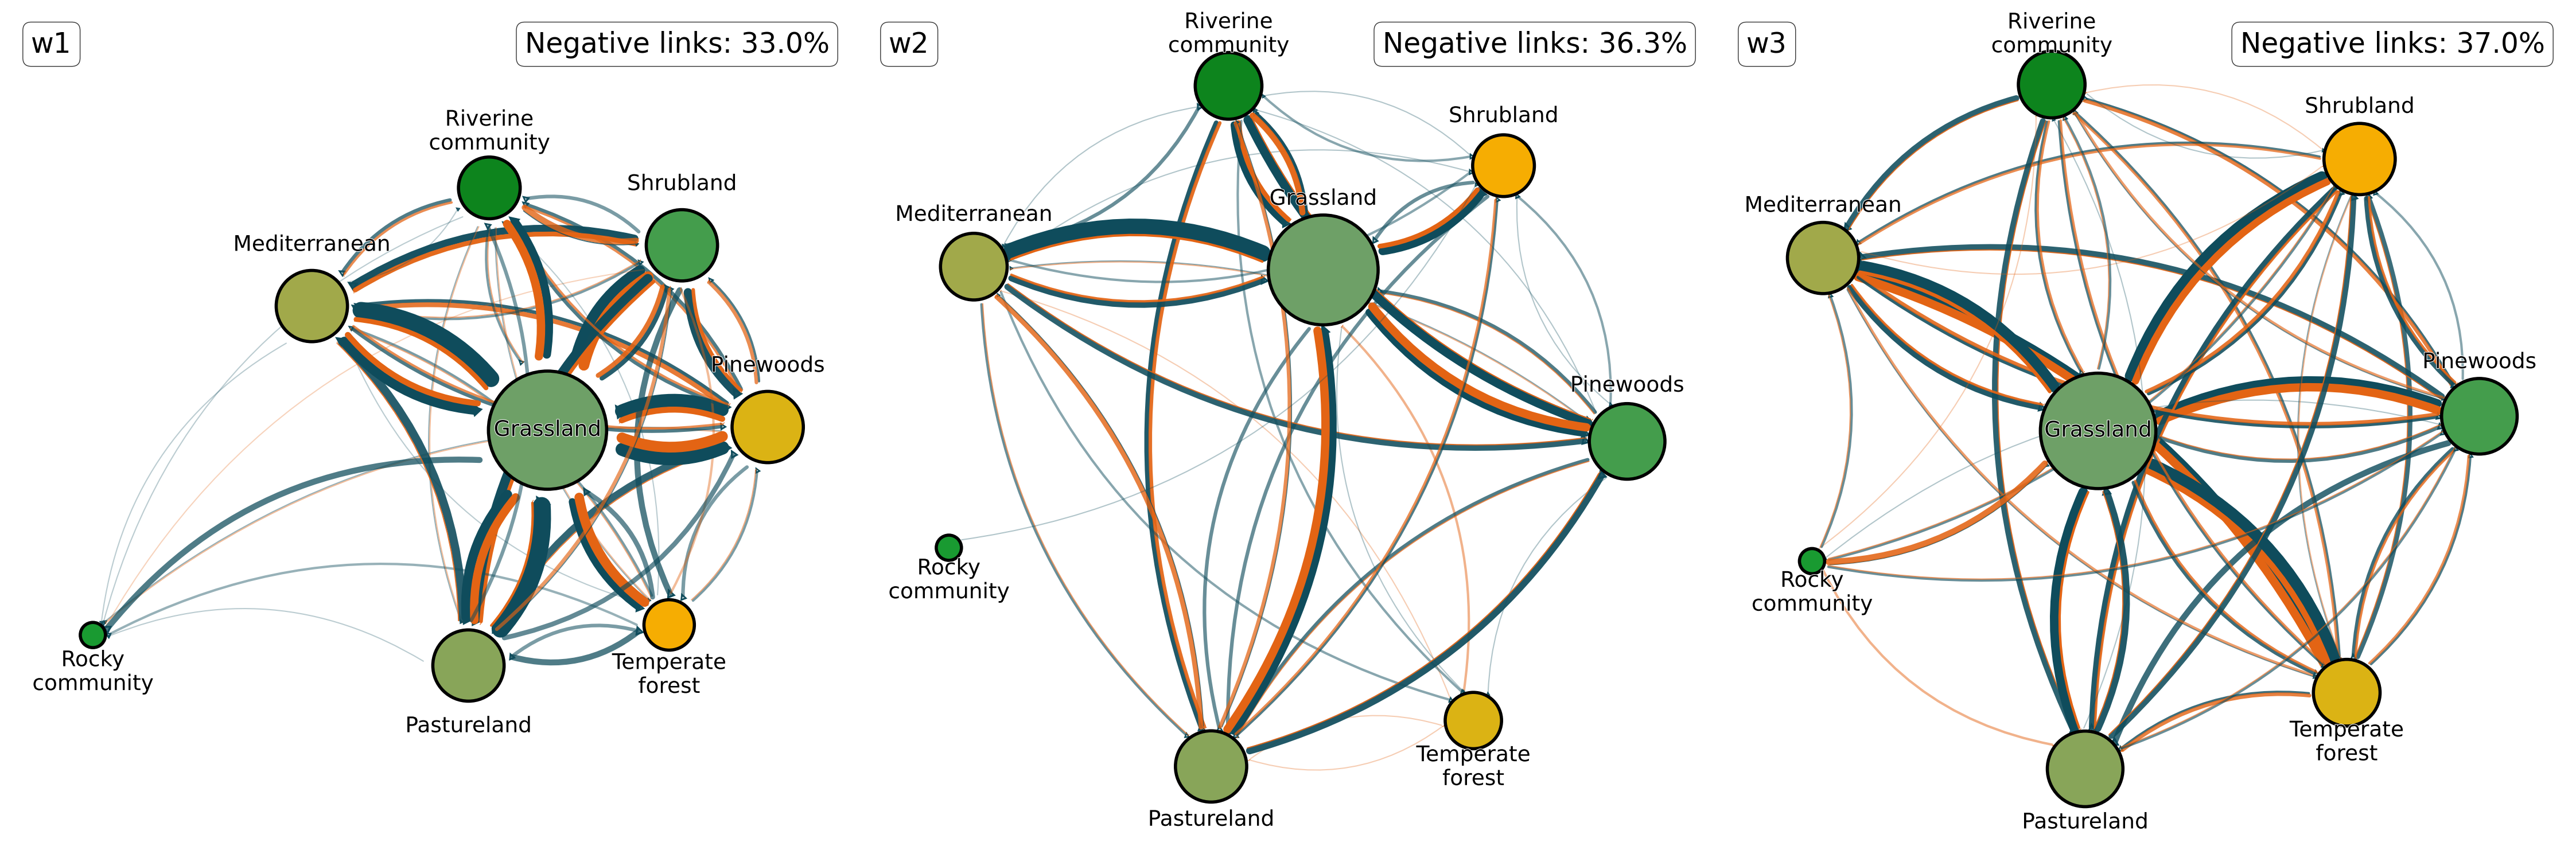

In [7]:
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors

# Importar las funciones personalizadas
from lib.halfarrowpatch import *  # Asegúrate de que esta importación funciona

# =====================================================
# FUNCIONES AUXILIARES (copiadas de tu código)
# =====================================================

def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) / 2
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L / 2
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, 
                    offset=0.0, node_radius_u=0.05, node_radius_v=0.05, 
                    arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

def sequential_custom_generator():
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows
    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[random_indices[index] % len(colors_list)])
        index += 1

# =====================================================
# CONFIG
# =====================================================

windows_names = ["w1", "w2", "w3"]

POS_COLOR = "#0F4C5C"  # Azul verdoso para positivas
NEG_COLOR = "#E36414"  # Naranja para negativas

# =====================================================
# COMUNIDADES
# =====================================================

groups_df = pd.read_csv("basa_groups.csv")
species_to_community = dict(zip(groups_df["Taxa"], groups_df["Community"]))

# =====================================================
# MAPEO DE COMUNIDADES A ÍNDICES Y ETIQUETAS
# =====================================================

# Crear mapeo inverso de comunidad a índice numérico
community_to_index = {
    'grassland': 0,
    'mediterranean': 1,
    'pastureland': 2,
    'pinewoods': 3,
    'riverine community': 4,
    'rocky community': 5,
    'shrubland': 6,
    'temperate forest': 7
}

# Mapeo de índice a etiqueta (igual que en el original)
labels = {
    7: 'Temperate\nforest',
    3: 'Pinewoods',
    6: 'Shrubland',
    4: 'Riverine\ncommunity',
    1: 'Mediterranean',
    2: 'Pastureland',
    0: 'Grassland',
    5: 'Rocky\ncommunity'
}

# Orden para las posiciones iniciales (igual que en el original)
order = {
    'Temperate\nforest': 1,
    'Pinewoods': 2,
    'Shrubland': 3,
    'Riverine\ncommunity': 4,
    'Mediterranean': 5,
    'Rocky\ncommunity': 6,
    'Pastureland': 7
}

# Mapeo inverso de comunidad a etiqueta
community_to_label = {
    'temperate forest': 'Temperate\nforest',
    'pinewoods': 'Pinewoods',
    'shrubland': 'Shrubland',
    'riverine community': 'Riverine\ncommunity',
    'mediterranean': 'Mediterranean',
    'rocky community': 'Rocky\ncommunity',
    'pastureland': 'Pastureland',
    'grassland': 'Grassland'
}

# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(45, 15))

for idx, window_name in enumerate(windows_names):
    ax = axes[idx]

    with open(f"results_{window_name}_def.pkl", "rb") as f:
        data = pickle.load(f)

    sig = np.array(data["matriz_significancia"])
    species_order = data["especies"]

    # =================================================
    # RED ESPECIES
    # =================================================

    G_species = nx.DiGraph()

    for sp in species_order:
        if sp in species_to_community:
            G_species.add_node(sp,
                community=species_to_community[sp])

    n = len(species_order)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            sp1 = species_order[i]
            sp2 = species_order[j]

            if sp1 not in species_to_community or sp2 not in species_to_community:
                continue

            sign = sig[i, j]

            if sign == 0:
                continue

            G_species.add_edge(sp1, sp2, sign=sign)

    # =================================================
    # CONTAR ESPECIES POR COMUNIDAD
    # =================================================

    community_counts = defaultdict(int)

    for node in G_species.nodes():
        comm = G_species.nodes[node]["community"]
        community_counts[comm] += 1

    # =================================================
    # RED COMUNIDADES
    # =================================================

    G = nx.MultiDiGraph()

    for comm, count in community_counts.items():
        G.add_node(comm, size=count)

    # Contar edges positivos y negativos entre comunidades
    edge_counts = defaultdict(lambda: {"pos": 0, "neg": 0})

    for u, v, data in G_species.edges(data=True):
        cu = G_species.nodes[u]["community"]
        cv = G_species.nodes[v]["community"]

        if cu == cv:
            continue

        if data["sign"] == 1:
            edge_counts[(cu, cv)]["pos"] += 1
        else:
            edge_counts[(cu, cv)]["neg"] += 1

    # Añadir edges a la red de comunidades
    for (u, v), counts in edge_counts.items():
        if counts["pos"] > 0:
            G.add_edge(u, v, color=POS_COLOR, weight=counts["pos"] * 1.5)
        if counts["neg"] > 0:
            G.add_edge(u, v, color=NEG_COLOR, weight=counts["neg"] * 1.5)

    # Eliminar edges con peso cero (por si acaso)
    for u, v, key, weight in G.copy().edges(data="weight", keys=True):
        if weight == 0:
            G.remove_edge(u, v, key)

    # =================================================
    # POSICIONES INICIALES (como en el original)
    # =================================================

    # Obtener lista de comunidades presentes
    communities_present = list(G.nodes())
    
    # Configurar posiciones iniciales
    initial_pos = {}
    
    # Grassland en el centro (índice 0)
    grassland_comm = None
    for comm in communities_present:
        if community_to_index[comm] == 0:
            grassland_comm = comm
            initial_pos[comm] = np.array([0.0, 0.0])
            break

    # Calcular posiciones para las demás comunidades
    if grassland_comm:
        N = len(communities_present)
        angle_step = 2 * np.pi / (N - 1)
        other_comms = [c for c in communities_present if c != grassland_comm]
        
        for comm in other_comms:
            idx = community_to_index[comm]
            label = labels[idx]
            # Asegurarse de que la etiqueta existe en order
            if label in order:
                angle = angle_step * (order[label] - 2)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])
            else:
                # Si no está en el orden, asignar posición aleatoria en el círculo
                angle = np.random.uniform(0, 2*np.pi)
                initial_pos[comm] = np.array([np.cos(angle), np.sin(angle)])

    # Aplicar spring layout con posiciones iniciales
    pos = nx.spring_layout(
        G,
        weight='weight',
        seed=1,
        pos=initial_pos,
        iterations=2
    )

    # =================================================
    # NODOS
    # =================================================

    node_sizes = {n: G.nodes[n]['size'] * 1000 for n in G.nodes()}
    
    # Generar colores para las comunidades
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1 / 700000
    scale = 0.00094  # escala para offsets

    # =================================================
    # ARISTAS (usando HalfArrowPatch)
    # =================================================

    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(
        sum(edge['weight'] for edge in edges)
        for edges in edge_groups.values()
    ) if edge_groups else 1

    # Dibujar aristas agrupadas por par de nodos
    for (u, v), edges in edge_groups.items():
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4 * total_width / max_total_weight), 1)

        if n == 1:
            # Una sola arista
            data = edges[0]
            # Usar arrowstyle según el color
            if data["color"] == POS_COLOR:
                arrow_style = '|/'  # Para positivas
            else:
                arrow_style = '|\\'  # Para negativas
            
            add_curved_edge(
                ax, pos, u, v,
                color=data["color"],
                weight=data["weight"],
                rad=0.25,
                angle=0,
                offset=0.0,
                node_radius_u=node_sizes[u] * node_size_scale,
                node_radius_v=node_sizes[v] * node_size_scale,
                arrowstyle=arrow_style,
                zorder=-1,
                alpha=alpha
            )

        elif n == 2:
            # Dos aristas: una positiva y una negativa
            # Separar por color para identificar positiva y negativa
            pos_edges = [e for e in edges if e["color"] == POS_COLOR]
            neg_edges = [e for e in edges if e["color"] == NEG_COLOR]
            
            sorted_edges = []
            if pos_edges:
                sorted_edges.append(pos_edges[0])
            if neg_edges:
                sorted_edges.append(neg_edges[0])
            
            if len(sorted_edges) == 2:
                w_0 = sorted_edges[0]["weight"]
                w_1 = sorted_edges[1]["weight"]
                
                # Calcular offsets para que queden paralelas
                offset = (w_0 + w_1 / 1.0) * scale
                
                np.random.seed(0)
                rad = np.random.uniform(0.15, 0.25)
                
                # Primera arista (normalmente la positiva)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[0]["color"],
                    weight=w_0,
                    rad=rad,
                    angle=0,
                    offset=-offset - 0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|/',  # Para la primera
                    zorder=-1,
                    alpha=alpha
                )
                
                # Segunda arista (normalmente la negativa)
                add_curved_edge(
                    ax, pos, u, v,
                    color=sorted_edges[1]["color"],
                    weight=w_1,
                    rad=rad,
                    angle=0,
                    offset=-0.02,
                    node_radius_u=node_sizes[u] * node_size_scale,
                    node_radius_v=node_sizes[v] * node_size_scale,
                    arrowstyle='|\\',  # Para la segunda
                    zorder=-1,
                    alpha=alpha
                )
            else:
                # Si por alguna razón solo hay un tipo de edge, dibujar como caso n=1
                for data in edges:
                    arrow_style = '|/' if data["color"] == POS_COLOR else '|\\'
                    add_curved_edge(
                        ax, pos, u, v,
                        color=data["color"],
                        weight=data["weight"],
                        rad=0.25,
                        angle=0,
                        offset=0.0,
                        node_radius_u=node_sizes[u] * node_size_scale,
                        node_radius_v=node_sizes[v] * node_size_scale,
                        arrowstyle=arrow_style,
                        zorder=-1,
                        alpha=alpha
                    )

    # =================================================
    # DIBUJAR NODOS
    # =================================================

    nx.draw_networkx_nodes(
        G, pos,
        node_color=[community_colors[node] for node in G.nodes()],
        ax=ax,
        node_size=[node_sizes[n] for n in G.nodes()],
        edgecolors="black",
        linewidths=4
    )

    # =================================================
    # ETIQUETAS CON OFFSET (como en el original)
    # =================================================

    label_pos = {}
    for n in G.nodes():
        # Calcular offset para la etiqueta
        if pos[n][1] > 0.1:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        elif pos[n][1] < -0.1:
            offset = np.array([0, -np.sqrt(node_sizes[n]) * 0.001 - 0.06])
        elif pos[n][0] > 0.2:
            offset = np.array([0, np.sqrt(node_sizes[n]) * 0.001 + 0.06])
        else:
            offset = np.array([0, 0.0])
            
        label_pos[n] = pos[n] + offset

    # Crear diccionario de etiquetas
    node_labels = {}
    for n in G.nodes():
        idx = community_to_index[n]
        node_labels[n] = labels[idx]

    texts = nx.draw_networkx_labels(
        G, label_pos,
        ax=ax,
        labels=node_labels,
        font_size=27,
        font_color='black'
    )

    for text in texts.values():
        text.set_path_effects([
            path_effects.Stroke(linewidth=1.5, foreground='white'),
            path_effects.Normal()
        ])

    # =================================================
    # AJUSTAR LÍMITES DEL GRÁFICO
    # =================================================

    # Hacer el gráfico cuadrado
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    width = xlim[1] - xlim[0]
    height = ylim[1] - ylim[0]
    
    if width > height:
        center_y = (ylim[0] + ylim[1]) / 2
        ax.set_ylim(center_y - width/2, center_y + width/2)
    else:
        center_x = (xlim[0] + xlim[1]) / 2
        ax.set_xlim(center_x - height/2, center_x + height/2)
    
    # Añadir margen
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)

    # =================================================
    # TEXTO INFORMATIVO
    # =================================================

    # Calcular porcentaje de links negativos (para la red de especies)
    negative_links = len([e for e in G_species.edges(data=True) if e[2]['sign'] < 0])
    total_links = G_species.number_of_edges()
    negative_percentage = negative_links / total_links if total_links > 0 else 0

    # Añadir título con el nombre de la ventana temporal
    ax.text(0.03, 0.97, window_name,
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Añadir porcentaje de links negativos
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.axis("off")

plt.tight_layout()
plt.show()

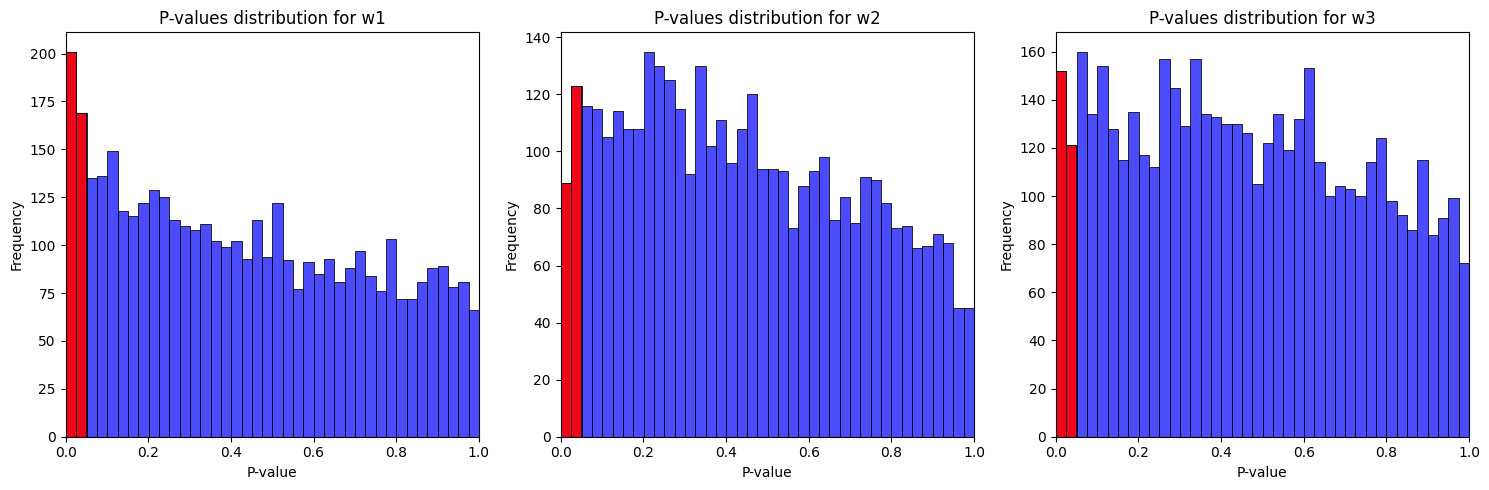

In [35]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_def.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_pvalores"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, binwidth=0.025, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [11]:
max(p_values), min(p_values)
sum(p_values >1)

np.int64(4)

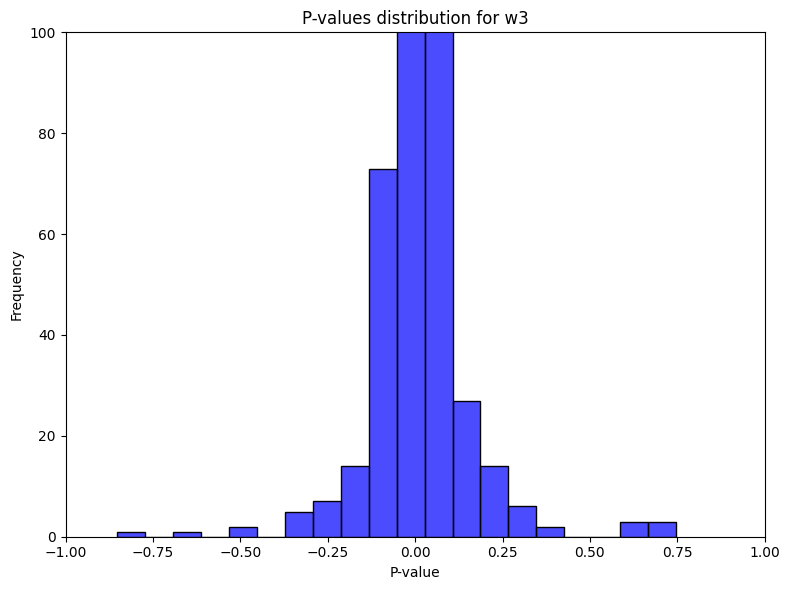

In [16]:
with open(f"results_w2_def_2.pkl", "rb") as f:
    data = pickle.load(f)

medias = np.array(data["matriz_medias"])
medias= medias.flatten()
medias = medias[~np.isnan(medias)]

#filtar entre -1 y 1
medias = medias[(medias >= -1) & (medias <= 1)]

plt.figure(figsize=(8, 6))
sns.histplot(medias, bins=20, color='blue', alpha=0.7, stat='count')
#sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
plt.title(f'P-values distribution for {window_name}')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.xlim(-1, 1)
plt.ylim(0,100)
plt.tight_layout()
plt.show()

In [15]:
min(medias), max(medias)

(np.float64(-0.8537650040481123), np.float64(0.7473581809940328))

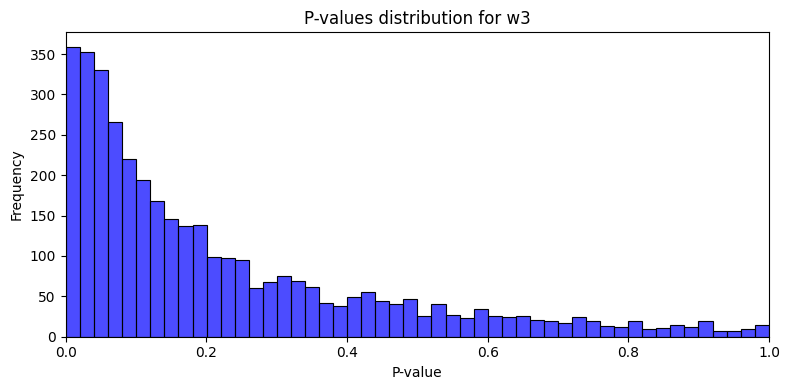

In [23]:
with open(f"results_w1_def_2.pkl", "rb") as f:
    data = pickle.load(f)

medias = np.array(data["matriz_std"])
medias= medias.flatten()
medias = medias[~np.isnan(medias)]

#filtar entre -1 y 1
medias = medias[(medias >= -1) & (medias <= 1)]

plt.figure(figsize=(8, 4))
sns.histplot(medias, bins=50, color='blue', alpha=0.7, stat='count')
#sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
plt.title(f'P-values distribution for {window_name}')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.xlim(0,1)
#plt.ylim(0,100)
plt.tight_layout()
plt.show()